# Rossmann Store Sales — SARIMA & Prophet

**Objectif :** Prédire les ventes d'un store avec deux approches séries temporelles classiques.

| Modèle | Approche | Forces |
|---|---|---|
| SARIMA | Statistique — modélise dépendances temporelles | Interprétable, bien théorisé |
| Prophet | Décomposition additive automatique | Gère multi-saisonnalité + fêtes facilement |

**Note :** Ces modèles travaillent sur **une série à la fois** (un store). Pour couvrir les 1115 stores, on les entraînerait en boucle.

In [13]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from prophet import Prophet

plt.rcParams['figure.dpi'] = 100
DATASET = 'dataset/'
STORE_ID = 1  # store analysé — tu peux changer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Préparation des données

In [14]:
train = pd.read_csv(DATASET + 'train.csv', parse_dates=['Date'], low_memory=False)

# Sélection du store + filtre jours ouverts
store_df = (
    train[(train['Store'] == STORE_ID) & (train['Open'] == 1) & (train['Sales'] > 0)]
    .copy()
    .sort_values('Date')
    .set_index('Date')
)

print(f'Store {STORE_ID} — {len(store_df)} jours disponibles')
print(f'Période : {store_df.index.min().date()} → {store_df.index.max().date()}')

Store 1 — 781 jours disponibles
Période : 2013-01-02 → 2015-07-31


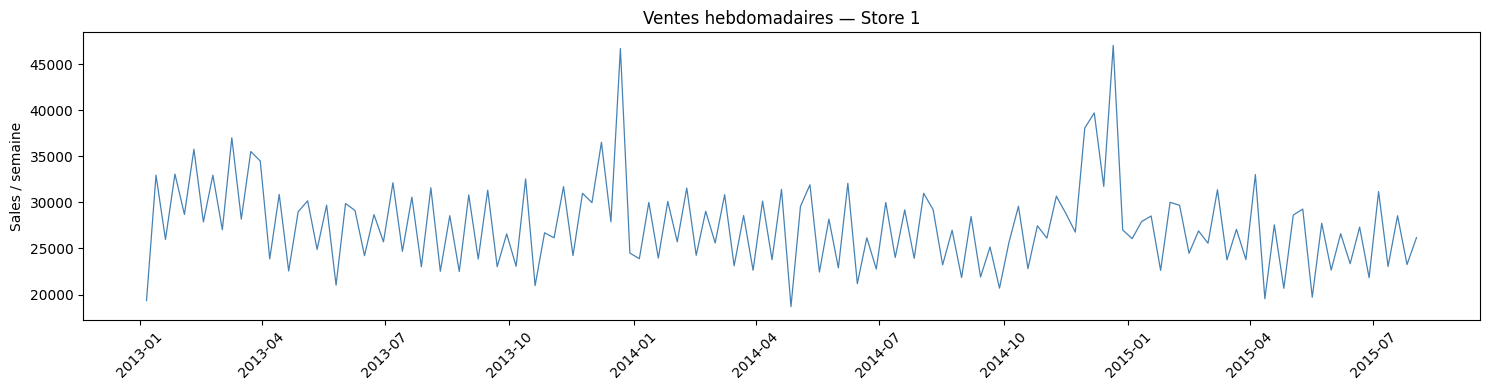

Semaines disponibles : 135


In [15]:
# Agrégation hebdomadaire (SARIMA sur données journalières avec trous = instable)
weekly = store_df['Sales'].resample('W').sum()

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(weekly.index, weekly.values, linewidth=0.9, color='steelblue')
ax.set_title(f'Ventes hebdomadaires — Store {STORE_ID}')
ax.set_ylabel('Sales / semaine')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Semaines disponibles : {len(weekly)}')

## 2. Split Train / Validation

On réserve les **6 dernières semaines** comme validation — identique au notebook LightGBM pour pouvoir comparer les scores.

In [16]:
n_val = 6
train_ts = weekly.iloc[:-n_val]
val_ts   = weekly.iloc[-n_val:]

print(f'Train : {len(train_ts)} semaines  |  Val : {len(val_ts)} semaines')
print(f'Validation : {val_ts.index[0].date()} → {val_ts.index[-1].date()}')

Train : 129 semaines  |  Val : 6 semaines
Validation : 2015-06-28 → 2015-08-02


---
# PARTIE 1 — SARIMA
---

## 3. Test de stationnarité (ADF)

SARIMA exige une série **stationnaire** (sans tendance ni variance croissante).  
Le test ADF (Augmented Dickey-Fuller) vérifie ça statistiquement.

- **p-value < 0.05** → série stationnaire ✓  
- **p-value ≥ 0.05** → il faut différencier (paramètre `d`)

In [17]:
def adf_test(series, label='Série'):
    result = adfuller(series.dropna())
    print(f'=== ADF Test — {label} ===')
    print(f'  Statistique ADF : {result[0]:.4f}')
    print(f'  p-value         : {result[1]:.4f}')
    print(f'  Seuils critiques: {result[4]}')
    if result[1] < 0.05:
        print('  → STATIONNAIRE ✓ (p < 0.05)\n')
    else:
        print('  → NON STATIONNAIRE ✗ — différenciation nécessaire\n')

adf_test(train_ts, 'Ventes hebdo brutes')
adf_test(train_ts.diff().dropna(), 'Ventes hebdo différenciées (d=1)')

=== ADF Test — Ventes hebdo brutes ===
  Statistique ADF : -5.2862
  p-value         : 0.0000
  Seuils critiques: {'1%': -3.482920063655088, '5%': -2.884580323367261, '10%': -2.5790575441750883}
  → STATIONNAIRE ✓ (p < 0.05)

=== ADF Test — Ventes hebdo différenciées (d=1) ===
  Statistique ADF : -10.6033
  p-value         : 0.0000
  Seuils critiques: {'1%': -3.4837793736959997, '5%': -2.88495387648, '10%': -2.579256976}
  → STATIONNAIRE ✓ (p < 0.05)



## 4. ACF & PACF — Choisir les paramètres p, q, P, Q

Les graphiques ACF et PACF guident le choix des paramètres :

- **PACF** → indique `p` (ordre AR) : nombre de lags significatifs avant coupure
- **ACF** → indique `q` (ordre MA) : nombre de lags significatifs avant coupure  
- Lags aux multiples de `m=52` → paramètres saisonniers P, Q

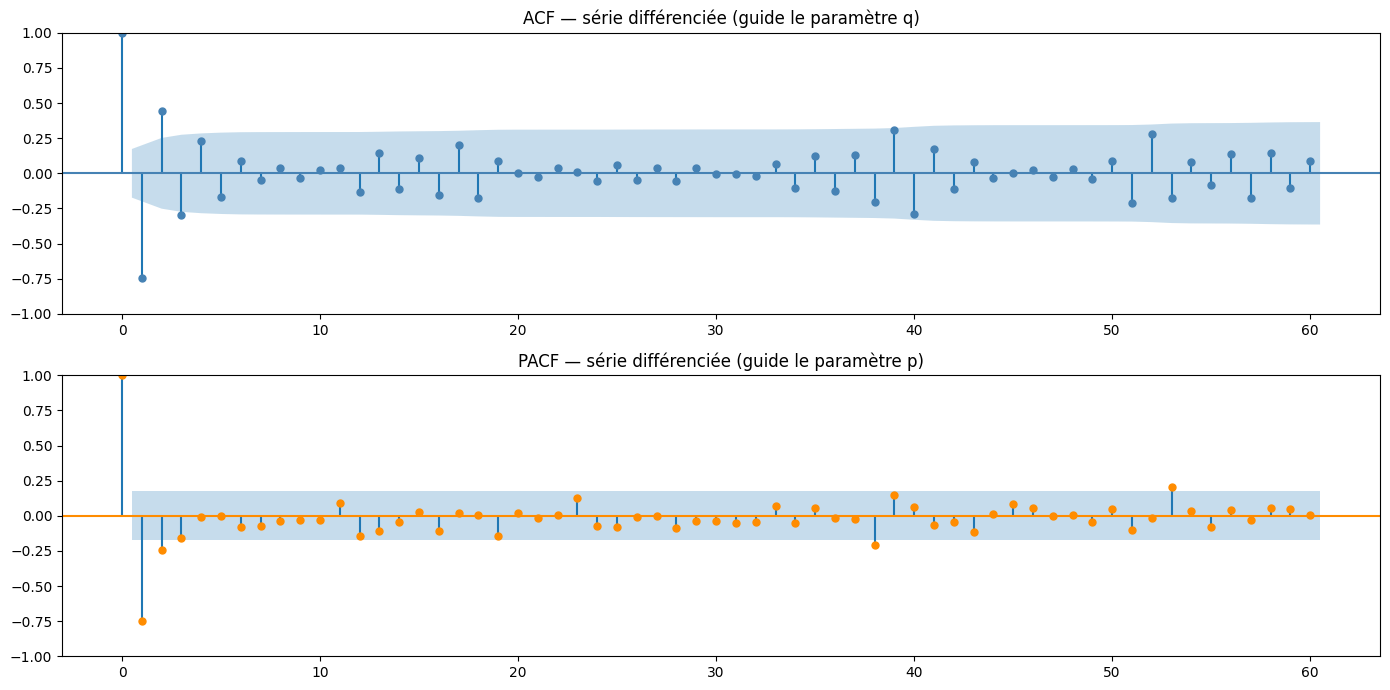

In [18]:
series_diff = train_ts.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

plot_acf(series_diff, lags=60, ax=axes[0], color='steelblue')
axes[0].set_title('ACF — série différenciée (guide le paramètre q)')

plot_pacf(series_diff, lags=60, ax=axes[1], color='darkorange', method='ywm')
axes[1].set_title('PACF — série différenciée (guide le paramètre p)')

plt.tight_layout()
plt.show()

## 5. Entraînement SARIMA

**Paramètres choisis : SARIMA(1,1,1)(1,1,0)[52]**

| Paramètre | Valeur | Signification |
|---|---|---|
| p=1 | 1 terme AR | dépendance à la semaine précédente |
| d=1 | 1 différenciation | élimine la tendance |
| q=1 | 1 terme MA | correction sur l'erreur précédente |
| P=1 | 1 terme AR saisonnier | dépendance à la même semaine l'an dernier |
| D=1 | 1 différenciation saisonnière | élimine la saisonnalité annuelle |
| Q=0 | pas de MA saisonnier | simplifie le modèle |
| m=52 | période saisonnière | 52 semaines = 1 an |

In [19]:
sarima_model = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)
print(sarima_result.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               Sales   No. Observations:                  129
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 52)   Log Likelihood                -216.479
Date:                             Wed, 15 Jul 2026   AIC                            440.958
Time:                                     16:52:58   BIC                            445.500
Sample:                                 01-06-2013   HQIC                           442.101
                                      - 06-21-2015                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4738      0.422     -1.122      0.262      -1.301       0.354
ma.L1         -0.9876      

## 6. Prédictions & Évaluation SARIMA

In [20]:
def rmspe(y_true, y_pred):
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

# Prédiction sur la période de validation
forecast = sarima_result.get_forecast(steps=n_val)
pred_sarima = forecast.predicted_mean
conf_int    = forecast.conf_int(alpha=0.05)  # intervalle de confiance 95%

score_sarima = rmspe(val_ts.values, pred_sarima.values)
print(f'RMSPE SARIMA (validation) : {score_sarima:.4f}  ({score_sarima*100:.2f}%)')

RMSPE SARIMA (validation) : 0.0723  (7.23%)


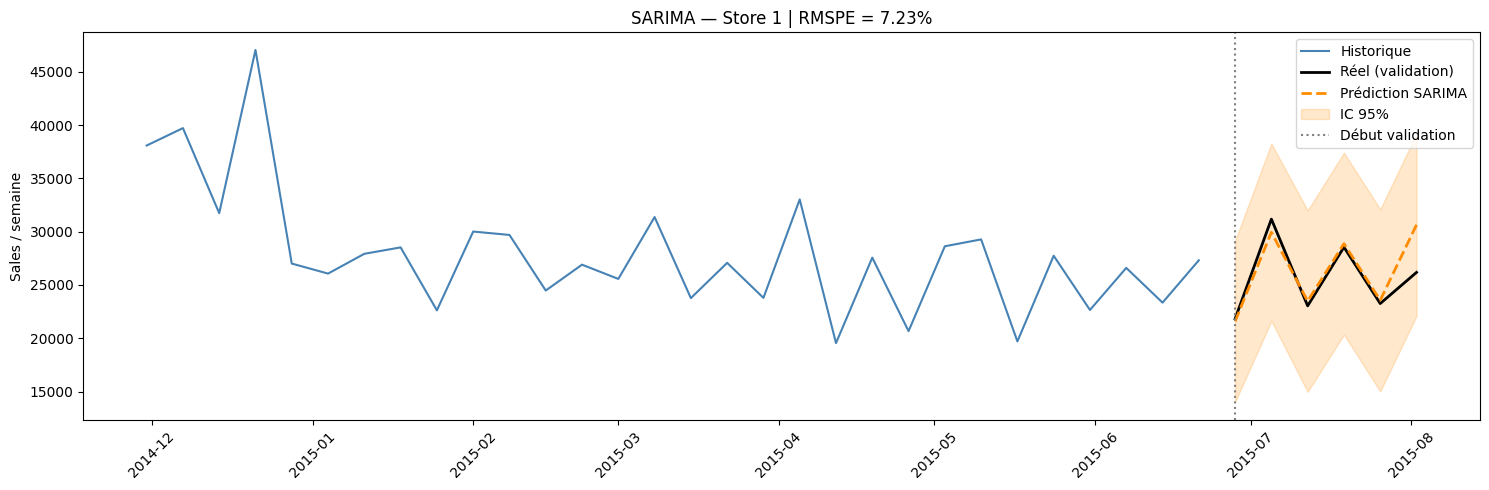

In [21]:
fig, ax = plt.subplots(figsize=(15, 5))

# Historique (dernières 30 semaines pour lisibilité)
ax.plot(train_ts.index[-30:], train_ts.values[-30:],
        label='Historique', color='steelblue')

# Valeurs réelles validation
ax.plot(val_ts.index, val_ts.values,
        label='Réel (validation)', color='black', linewidth=2)

# Prédictions SARIMA
ax.plot(pred_sarima.index, pred_sarima.values,
        label='Prédiction SARIMA', color='darkorange', linewidth=2, linestyle='--')

# Intervalle de confiance
ax.fill_between(conf_int.index,
                conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                alpha=0.2, color='darkorange', label='IC 95%')

ax.axvline(x=val_ts.index[0], color='gray', linestyle=':', label='Début validation')
ax.set_title(f'SARIMA — Store {STORE_ID} | RMSPE = {score_sarima*100:.2f}%')
ax.set_ylabel('Sales / semaine')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

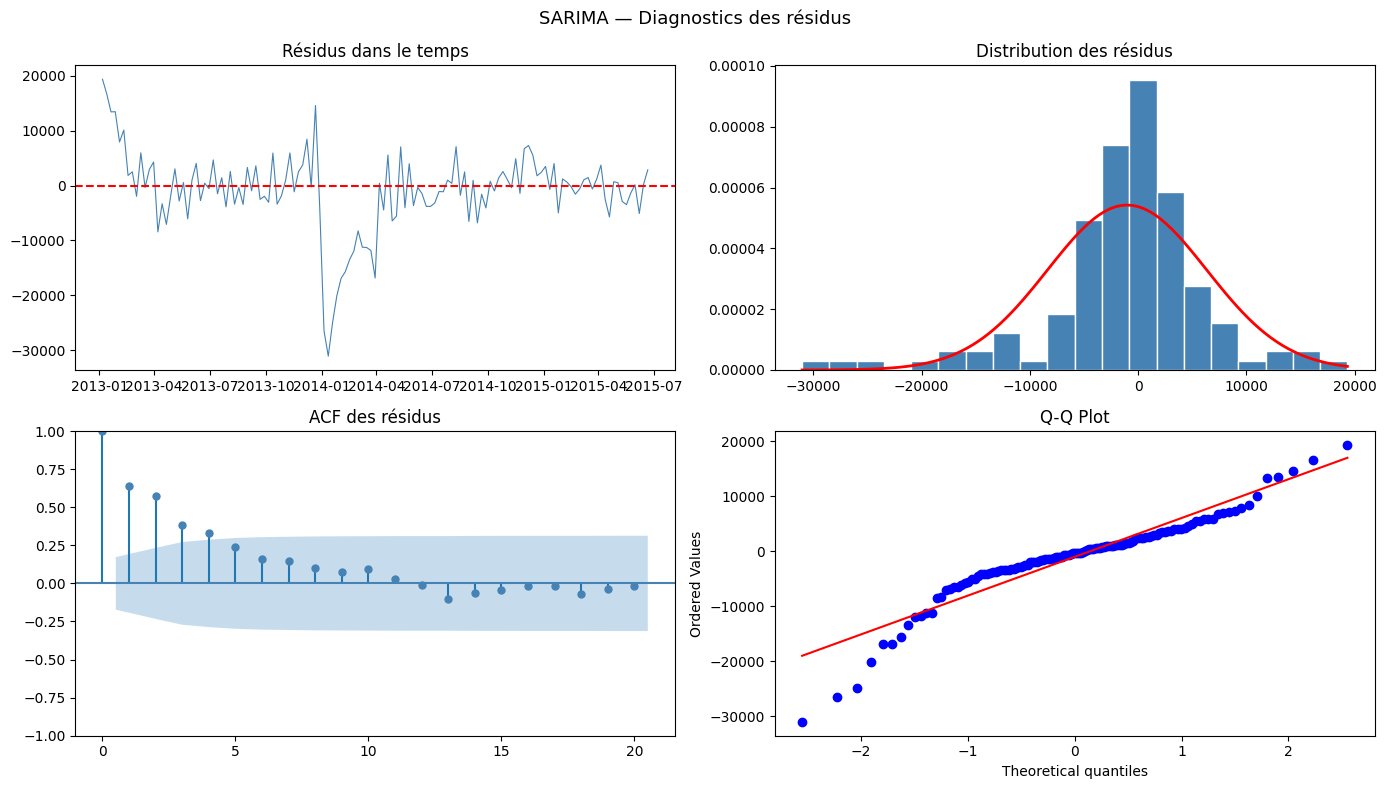

In [22]:
resid = sarima_result.resid.dropna()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(resid.index, resid.values, color='steelblue', linewidth=0.8)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Résidus dans le temps')

axes[0, 1].hist(resid, bins=20, color='steelblue', edgecolor='white', density=True)
from scipy.stats import norm
x = np.linspace(resid.min(), resid.max(), 100)
axes[0, 1].plot(x, norm.pdf(x, resid.mean(), resid.std()), color='red', linewidth=2)
axes[0, 1].set_title('Distribution des résidus')

plot_acf(resid, lags=20, ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('ACF des résidus')

from scipy.stats import probplot
probplot(resid, plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.suptitle('SARIMA — Diagnostics des résidus', fontsize=13)
plt.tight_layout()
plt.show()

**Lecture des diagnostics :**
- **Résidus standardisés** → doivent être aléatoires autour de 0 (pas de pattern)
- **Histogramme + KDE** → résidus doivent suivre une distribution normale
- **Q-Q plot** → les points doivent être alignés sur la droite diagonale
- **Corrélogramme** → pas de pic significatif au-delà des bandes bleues

---
# PARTIE 2 — Facebook Prophet
---

## 7. Préparation des données Prophet

Prophet exige un DataFrame avec exactement deux colonnes : `ds` (date) et `y` (valeur à prédire).

In [23]:
# Données journalières pour Prophet (il gère mieux les trous que SARIMA)
daily = (
    store_df[['Sales', 'Promo']]
    .reset_index()
    .rename(columns={'Date': 'ds', 'Sales': 'y'})
)

# Split temporel — dernières 6 semaines = validation
cutoff = daily['ds'].max() - pd.Timedelta(weeks=6)
train_prophet = daily[daily['ds'] <= cutoff]
val_prophet   = daily[daily['ds'] > cutoff]

print(f'Train Prophet : {len(train_prophet)} jours')
print(f'Val Prophet   : {len(val_prophet)} jours')
train_prophet.head()

Train Prophet : 745 jours
Val Prophet   : 36 jours


,ds,y,Promo
0,2013-01-02,5530,0
1,2013-01-03,4327,0
2,2013-01-04,4486,0
3,2013-01-05,4997,0
4,2013-01-07,7176,1


## 8. Jours fériés allemands

Rossmann est une chaîne allemande — on ajoute les jours fériés pour que Prophet apprenne leur effet sur les ventes.

In [24]:
# Jours fériés allemands présents dans le dataset (2013–2015)
german_holidays = pd.DataFrame({
    'holiday': [
        'Noël', 'Noël', 'Nouvel An', 'Nouvel An',
        'Paques', 'Paques', 'Paques', 'Paques',
        'Fete du Travail', 'Fete du Travail', 'Fete du Travail',
        'Noel_veille', 'Noel_veille'
    ],
    'ds': pd.to_datetime([
        '2013-12-25', '2014-12-25',
        '2013-01-01', '2014-01-01',
        '2013-03-29', '2013-04-01', '2014-04-18', '2014-04-21',
        '2013-05-01', '2014-05-01', '2015-05-01',
        '2013-12-24', '2014-12-24'
    ]),
    'lower_window': [-2, -2, 0, 0, -1, 0, -1, 0, 0, 0, 0, 0, 0],
    'upper_window': [1,  1,  1, 1,  0, 1,  0, 1, 1, 1, 1, 1, 1]
})

print(f'{len(german_holidays)} événements fériés définis')
german_holidays

13 événements fériés définis


,holiday,ds,lower_window,upper_window
0,Noël,2013-12-25,-2,1
1,Noël,2014-12-25,-2,1
2,Nouvel An,2013-01-01,0,1
3,Nouvel An,2014-01-01,0,1
4,Paques,2013-03-29,-1,0
5,Paques,2013-04-01,0,1
6,Paques,2014-04-18,-1,0
7,Paques,2014-04-21,0,1
8,Fete du Travail,2013-05-01,0,1
9,Fete du Travail,2014-05-01,0,1


## 9. Entraînement Prophet

In [25]:
prophet_model = Prophet(
    yearly_seasonality=True,    # saisonnalité annuelle (Noël, été...)
    weekly_seasonality=True,    # saisonnalité hebdomadaire (lun > dim)
    daily_seasonality=False,    # pas de pattern intra-journalier
    holidays=german_holidays,
    seasonality_mode='multiplicative',  # saisonnalité proportionnelle au niveau
    changepoint_prior_scale=0.05,       # flexibilité de la tendance
    seasonality_prior_scale=10,         # force de la saisonnalité
    holidays_prior_scale=10,            # force de l'effet fêtes
)

# Ajouter la promo comme régresseur externe
prophet_model.add_regressor('Promo')

prophet_model.fit(train_prophet[['ds', 'y', 'Promo']])
print('Modèle Prophet entraîné ✓')

16:53:00 - cmdstanpy - INFO - Chain [1] start processing
16:53:00 - cmdstanpy - INFO - Chain [1] done processing


Modèle Prophet entraîné ✓


## 10. Prédictions & Évaluation Prophet

In [26]:
# Prédire sur la période de validation (avec les vraies valeurs de Promo)
future = val_prophet[['ds', 'Promo']].copy()
forecast_prophet = prophet_model.predict(future)

pred_prophet = forecast_prophet['yhat'].clip(lower=0).values
score_prophet = rmspe(val_prophet['y'].values, pred_prophet)

print(f'RMSPE Prophet (validation) : {score_prophet:.4f}  ({score_prophet*100:.2f}%)')

RMSPE Prophet (validation) : 0.0938  (9.38%)


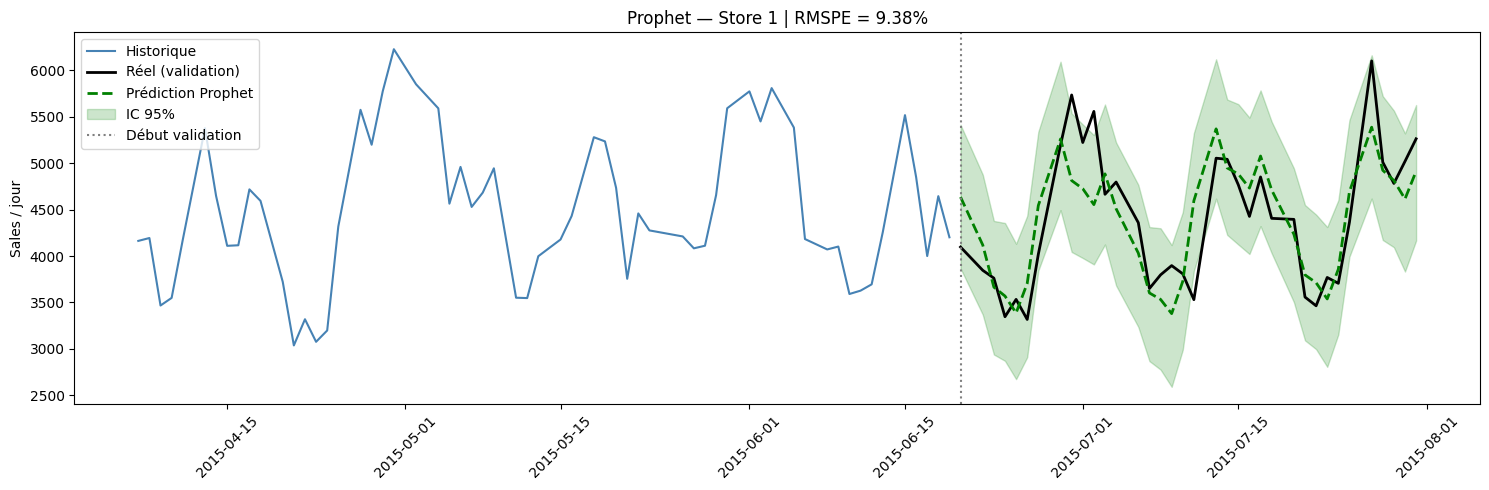

In [27]:
fig, ax = plt.subplots(figsize=(15, 5))

# Historique (derniers 60 jours)
hist = train_prophet.tail(60)
ax.plot(hist['ds'], hist['y'], label='Historique', color='steelblue')

# Valeurs réelles validation
ax.plot(val_prophet['ds'], val_prophet['y'],
        label='Réel (validation)', color='black', linewidth=2)

# Prédictions Prophet
ax.plot(forecast_prophet['ds'], forecast_prophet['yhat'],
        label='Prédiction Prophet', color='green', linewidth=2, linestyle='--')

# Intervalle de confiance
ax.fill_between(forecast_prophet['ds'],
                forecast_prophet['yhat_lower'].clip(0),
                forecast_prophet['yhat_upper'],
                alpha=0.2, color='green', label='IC 95%')

ax.axvline(x=val_prophet['ds'].iloc[0], color='gray', linestyle=':', label='Début validation')
ax.set_title(f'Prophet — Store {STORE_ID} | RMSPE = {score_prophet*100:.2f}%')
ax.set_ylabel('Sales / jour')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Décomposition Prophet — Tendance + Saisonnalités

C'est l'un des grands avantages de Prophet : visualiser chaque composante séparément.

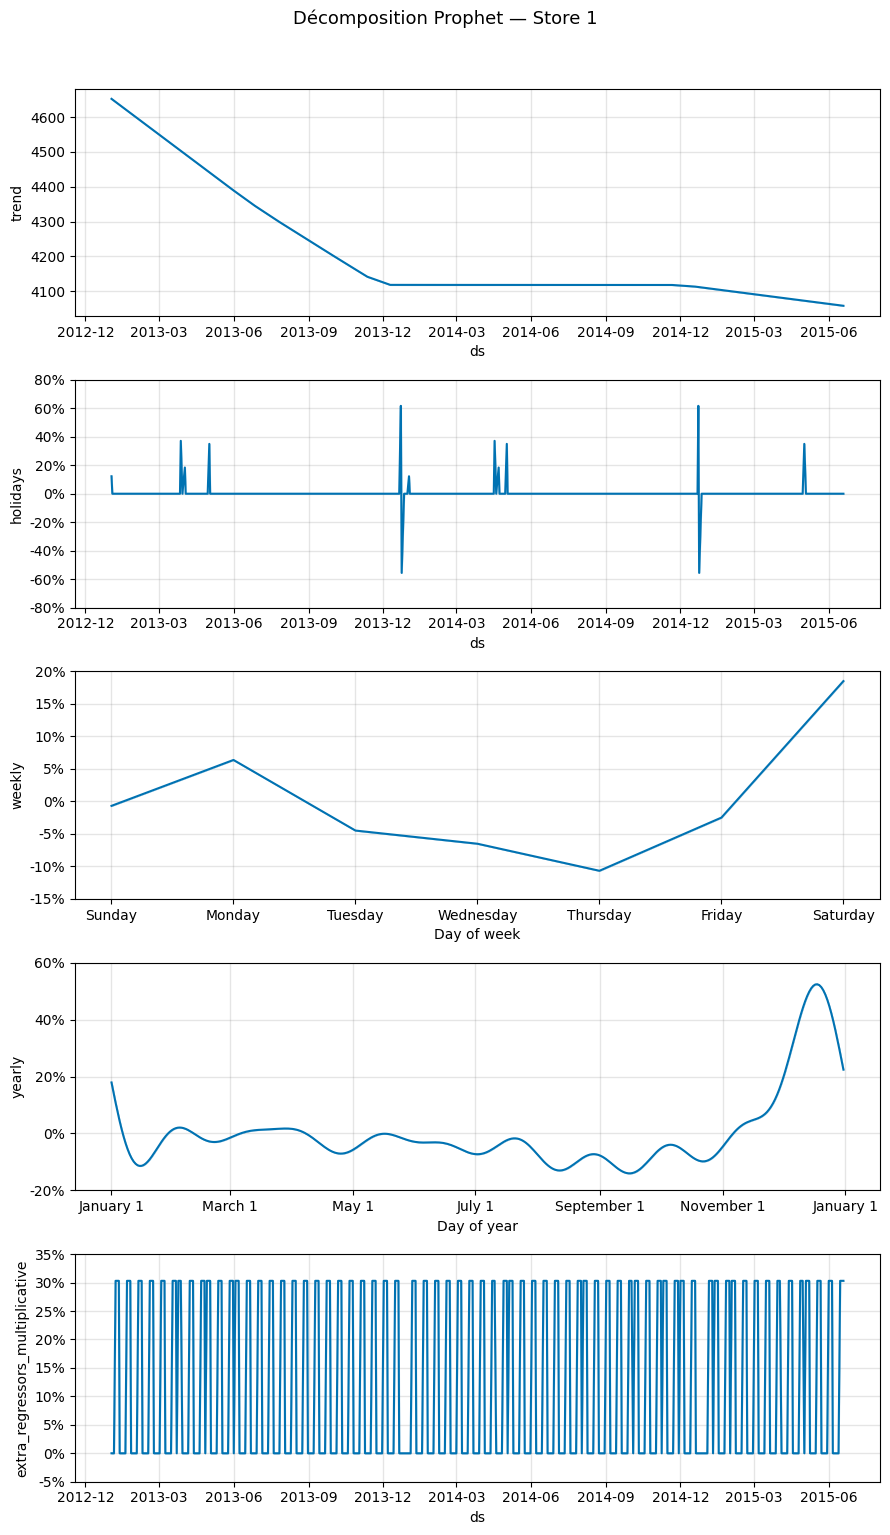

In [28]:
# Prédire sur tout l'historique pour voir la décomposition
full_future = train_prophet[['ds', 'Promo']].copy()
full_forecast = prophet_model.predict(full_future)

fig = prophet_model.plot_components(full_forecast)
fig.suptitle(f'Décomposition Prophet — Store {STORE_ID}', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Lecture des composantes :**
- **Tendance** → évolution long terme des ventes (hausse ou baisse structurelle)
- **Saisonnalité hebdomadaire** → quel jour de la semaine vend le mieux
- **Saisonnalité annuelle** → quels mois de l'année vendent le mieux
- **Holidays** → impact de chaque jour férié défini

---
## 12. Comparaison des modèles

In [29]:
results = pd.DataFrame({
    'Modèle': ['SARIMA(1,1,1)(1,1,0)[52]', 'Prophet + Promo + Fêtes'],
    'Granularité': ['Hebdomadaire', 'Journalière'],
    'RMSPE (%)': [round(score_sarima * 100, 2), round(score_prophet * 100, 2)],
    'Features externes': ['Non', 'Promo, jours fériés'],
    'Scalable (1115 stores)': ['Lent', 'Rapide']
})

print(results.to_string(index=False))

                  Modèle  Granularité  RMSPE (%)   Features externes Scalable (1115 stores)
SARIMA(1,1,1)(1,1,0)[52] Hebdomadaire       7.23                 Non                   Lent
 Prophet + Promo + Fêtes  Journalière       9.38 Promo, jours fériés                 Rapide


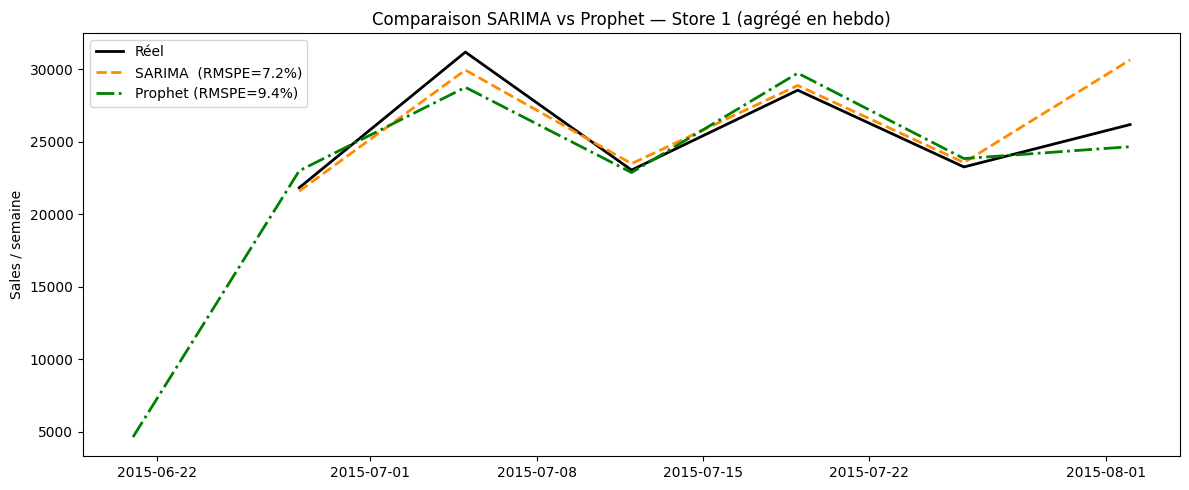

In [30]:
# Comparaison visuelle sur la période de validation
# (SARIMA hebdo vs Prophet journalier — on agrège Prophet en hebdo pour comparer)
prophet_weekly = (
    pd.Series(pred_prophet, index=pd.to_datetime(val_prophet['ds'].values))
    .resample('W')
    .sum()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(val_ts.index, val_ts.values, label='Réel', color='black', linewidth=2)
ax.plot(pred_sarima.index, pred_sarima.values,
        label=f'SARIMA  (RMSPE={score_sarima*100:.1f}%)', color='darkorange',
        linewidth=2, linestyle='--')
ax.plot(prophet_weekly.index, prophet_weekly.values,
        label=f'Prophet (RMSPE={score_prophet*100:.1f}%)', color='green',
        linewidth=2, linestyle='-.')
ax.set_title(f'Comparaison SARIMA vs Prophet — Store {STORE_ID} (agrégé en hebdo)')
ax.set_ylabel('Sales / semaine')
ax.legend()
plt.tight_layout()
plt.show()

## 13. Quand utiliser quel modèle ?

| Situation | Modèle recommandé |
|---|---|
| 1 store, besoin d'intervalles de confiance précis | SARIMA |
| Plusieurs stores, jours fériés à modéliser | Prophet |
| Nombreuses features externes (promo, météo…) | LightGBM |
| Meilleure performance pure sur 1115 stores | LightGBM |
| Résultats interprétables pour un client non-tech | Prophet (décomposition) |

---
# PARTIE 3 — Prophet sur tous les stores (1115 stores)

> **Durée estimée : 20-40 minutes** selon la machine.  
> Les modèles sont sauvegardés au fur et à mesure — si le kernel s'arrête, les stores déjà traités sont conservés.

In [31]:
import joblib, os

os.makedirs('models', exist_ok=True)

store_ids   = sorted(train['Store'].unique())
models_dict = {}   # {store_id: Prophet model}
results_all = []
errors      = []

for i, store_id in enumerate(store_ids):
    try:
        store_data = (
            train[(train['Store'] == store_id) & (train['Open'] == 1) & (train['Sales'] > 0)]
            .copy()
            .sort_values('Date')
            [['Date', 'Sales', 'Promo']]
            .rename(columns={'Date': 'ds', 'Sales': 'y'})
            .reset_index(drop=True)
        )

        if len(store_data) < 90:
            continue

        cutoff  = store_data['ds'].max() - pd.Timedelta(weeks=6)
        train_s = store_data[store_data['ds'] <= cutoff]
        val_s   = store_data[store_data['ds'] > cutoff]

        if len(val_s) == 0:
            continue

        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            holidays=german_holidays,
            seasonality_mode='multiplicative',
            changepoint_prior_scale=0.05,
            seasonality_prior_scale=10,
            holidays_prior_scale=10,
        )
        m.add_regressor('Promo')
        m.fit(train_s[['ds', 'y', 'Promo']])

        preds = m.predict(val_s[['ds', 'Promo']])['yhat'].clip(lower=0).values
        score = rmspe(val_s['y'].values, preds)

        models_dict[store_id] = m
        results_all.append({
            'store_id':   store_id,
            'rmspe':      round(score, 4),
            'n_train':    len(train_s),
            'n_val':      len(val_s),
            'trained_on': str(train_s['ds'].max().date()),
        })

    except Exception as e:
        errors.append({'store_id': store_id, 'error': str(e)})

    if (i + 1) % 100 == 0 or (i + 1) == len(store_ids):
        print(f'[{i+1}/{len(store_ids)}] — {len(models_dict)} modeles en memoire')

print(f'Termine. {len(models_dict)} modeles, {len(errors)} erreurs.')
results_df = pd.DataFrame(results_all)


22:39:05 - cmdstanpy - INFO - Chain [1] start processing
22:39:06 - cmdstanpy - INFO - Chain [1] done processing
22:39:06 - cmdstanpy - INFO - Chain [1] start processing
22:39:06 - cmdstanpy - INFO - Chain [1] done processing
22:39:07 - cmdstanpy - INFO - Chain [1] start processing
22:39:07 - cmdstanpy - INFO - Chain [1] done processing
22:39:07 - cmdstanpy - INFO - Chain [1] start processing
22:39:07 - cmdstanpy - INFO - Chain [1] done processing
22:39:07 - cmdstanpy - INFO - Chain [1] start processing
22:39:07 - cmdstanpy - INFO - Chain [1] done processing
22:39:08 - cmdstanpy - INFO - Chain [1] start processing
22:39:08 - cmdstanpy - INFO - Chain [1] done processing
22:39:08 - cmdstanpy - INFO - Chain [1] start processing
22:39:08 - cmdstanpy - INFO - Chain [1] done processing
22:39:08 - cmdstanpy - INFO - Chain [1] start processing
22:39:09 - cmdstanpy - INFO - Chain [1] done processing
22:39:09 - cmdstanpy - INFO - Chain [1] start processing
22:39:09 - cmdstanpy - INFO - Chain [1]

[100/1115] stores traités — 100 modèles sauvegardés


22:39:41 - cmdstanpy - INFO - Chain [1] done processing
22:39:41 - cmdstanpy - INFO - Chain [1] start processing
22:39:41 - cmdstanpy - INFO - Chain [1] done processing
22:39:41 - cmdstanpy - INFO - Chain [1] start processing
22:39:42 - cmdstanpy - INFO - Chain [1] done processing
22:39:42 - cmdstanpy - INFO - Chain [1] start processing
22:39:42 - cmdstanpy - INFO - Chain [1] done processing
22:39:42 - cmdstanpy - INFO - Chain [1] start processing
22:39:42 - cmdstanpy - INFO - Chain [1] done processing
22:39:43 - cmdstanpy - INFO - Chain [1] start processing
22:39:43 - cmdstanpy - INFO - Chain [1] done processing
22:39:43 - cmdstanpy - INFO - Chain [1] start processing
22:39:43 - cmdstanpy - INFO - Chain [1] done processing
22:39:43 - cmdstanpy - INFO - Chain [1] start processing
22:39:43 - cmdstanpy - INFO - Chain [1] done processing
22:39:44 - cmdstanpy - INFO - Chain [1] start processing
22:39:44 - cmdstanpy - INFO - Chain [1] done processing
22:39:44 - cmdstanpy - INFO - Chain [1] 

[200/1115] stores traités — 200 modèles sauvegardés


22:40:15 - cmdstanpy - INFO - Chain [1] done processing
22:40:15 - cmdstanpy - INFO - Chain [1] start processing
22:40:15 - cmdstanpy - INFO - Chain [1] done processing
22:40:15 - cmdstanpy - INFO - Chain [1] start processing
22:40:16 - cmdstanpy - INFO - Chain [1] done processing
22:40:16 - cmdstanpy - INFO - Chain [1] start processing
22:40:16 - cmdstanpy - INFO - Chain [1] done processing
22:40:16 - cmdstanpy - INFO - Chain [1] start processing
22:40:16 - cmdstanpy - INFO - Chain [1] done processing
22:40:17 - cmdstanpy - INFO - Chain [1] start processing
22:40:17 - cmdstanpy - INFO - Chain [1] done processing
22:40:17 - cmdstanpy - INFO - Chain [1] start processing
22:40:17 - cmdstanpy - INFO - Chain [1] done processing
22:40:17 - cmdstanpy - INFO - Chain [1] start processing
22:40:17 - cmdstanpy - INFO - Chain [1] done processing
22:40:18 - cmdstanpy - INFO - Chain [1] start processing
22:40:18 - cmdstanpy - INFO - Chain [1] done processing
22:40:18 - cmdstanpy - INFO - Chain [1] 

...

[1000/1115] stores traités — 1000 modèles sauvegardés


22:45:11 - cmdstanpy - INFO - Chain [1] done processing
22:45:12 - cmdstanpy - INFO - Chain [1] start processing
22:45:12 - cmdstanpy - INFO - Chain [1] done processing
22:45:12 - cmdstanpy - INFO - Chain [1] start processing
22:45:12 - cmdstanpy - INFO - Chain [1] done processing
22:45:12 - cmdstanpy - INFO - Chain [1] start processing
22:45:12 - cmdstanpy - INFO - Chain [1] done processing
22:45:13 - cmdstanpy - INFO - Chain [1] start processing
22:45:13 - cmdstanpy - INFO - Chain [1] done processing
22:45:13 - cmdstanpy - INFO - Chain [1] start processing
22:45:13 - cmdstanpy - INFO - Chain [1] done processing
22:45:13 - cmdstanpy - INFO - Chain [1] start processing
22:45:13 - cmdstanpy - INFO - Chain [1] done processing
22:45:14 - cmdstanpy - INFO - Chain [1] start processing
22:45:14 - cmdstanpy - INFO - Chain [1] done processing
22:45:14 - cmdstanpy - INFO - Chain [1] start processing
22:45:14 - cmdstanpy - INFO - Chain [1] done processing
22:45:14 - cmdstanpy - INFO - Chain [1] 

[1100/1115] stores traités — 1100 modèles sauvegardés


22:45:47 - cmdstanpy - INFO - Chain [1] done processing
22:45:47 - cmdstanpy - INFO - Chain [1] start processing
22:45:47 - cmdstanpy - INFO - Chain [1] done processing
22:45:47 - cmdstanpy - INFO - Chain [1] start processing
22:45:47 - cmdstanpy - INFO - Chain [1] done processing
22:45:48 - cmdstanpy - INFO - Chain [1] start processing
22:45:48 - cmdstanpy - INFO - Chain [1] done processing
22:45:48 - cmdstanpy - INFO - Chain [1] start processing
22:45:48 - cmdstanpy - INFO - Chain [1] done processing
22:45:48 - cmdstanpy - INFO - Chain [1] start processing
22:45:49 - cmdstanpy - INFO - Chain [1] done processing
22:45:49 - cmdstanpy - INFO - Chain [1] start processing
22:45:49 - cmdstanpy - INFO - Chain [1] done processing
22:45:49 - cmdstanpy - INFO - Chain [1] start processing
22:45:49 - cmdstanpy - INFO - Chain [1] done processing
22:45:49 - cmdstanpy - INFO - Chain [1] start processing
22:45:50 - cmdstanpy - INFO - Chain [1] done processing
22:45:50 - cmdstanpy - INFO - Chain [1] 

[1115/1115] stores traités — 1115 modèles sauvegardés

Terminé. 1115 modèles entraînés, 0 erreurs.


=== RMSPE sur tous les stores ===
count    111500.00%
mean         13.97%
std           5.63%
min           5.95%
25%          10.94%
50%          12.80%
75%          15.47%
max          74.21%
Name: rmspe, dtype: object

Meilleur store  : 948 (5.95%)
Pire store      : 292 (74.21%)


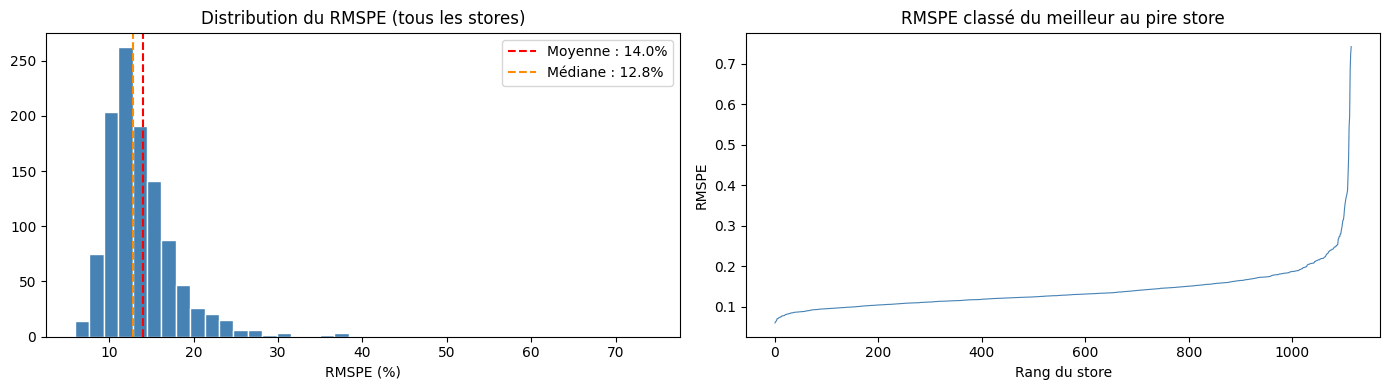

In [32]:
# Résumé global des performances
print('=== RMSPE sur tous les stores ===')
print(results_df['rmspe'].describe().apply(lambda x: f'{x*100:.2f}%'))
print(f'\nMeilleur store  : {results_df.loc[results_df["rmspe"].idxmin(), "store_id"]} '
      f'({results_df["rmspe"].min()*100:.2f}%)')
print(f'Pire store      : {results_df.loc[results_df["rmspe"].idxmax(), "store_id"]} '
      f'({results_df["rmspe"].max()*100:.2f}%)')

# Distribution des RMSPE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(results_df['rmspe'] * 100, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(results_df['rmspe'].mean() * 100, color='red',
                linestyle='--', label=f'Moyenne : {results_df["rmspe"].mean()*100:.1f}%')
axes[0].axvline(results_df['rmspe'].median() * 100, color='darkorange',
                linestyle='--', label=f'Médiane : {results_df["rmspe"].median()*100:.1f}%')
axes[0].set_title('Distribution du RMSPE (tous les stores)')
axes[0].set_xlabel('RMSPE (%)')
axes[0].legend()

results_df.sort_values('rmspe')['rmspe'].reset_index(drop=True).plot(
    ax=axes[1], color='steelblue', linewidth=0.8
)
axes[1].set_title('RMSPE classé du meilleur au pire store')
axes[1].set_xlabel('Rang du store')
axes[1].set_ylabel('RMSPE')

plt.tight_layout()
plt.show()

In [33]:
bundle = {
    'models':  models_dict,
    'results': results_df,
    'errors':  errors,
}
joblib.dump(bundle, 'models/all_prophet_models.joblib')
results_df.to_csv('models/all_prophet_models_summary.csv', index=False)

print(f'Sauvegarde -> models/all_prophet_models.joblib')
print(f'{len(models_dict)} modeles dans le dictionnaire')
print(f'Cles : {sorted(models_dict.keys())[:5]} ... {sorted(models_dict.keys())[-5:]}')

# Rechargement :
# bundle = joblib.load('models/all_prophet_models.joblib')
# model_store1 = bundle['models'][1]
# results      = bundle['results']


Résumé sauvegardé → models/prophet_all_stores/summary.csv

Top 10 meilleurs stores :
 store_id  rmspe  n_train
      948 0.0595      885
     1097 0.0623      900
      172 0.0635      586
      423 0.0651      900
      259 0.0698      889
      245 0.0702      745
      260 0.0702      748
      498 0.0716      586
      116 0.0726      747
      923 0.0733      748

Top 10 pires stores :
 store_id  rmspe  n_train
      292 0.7421      730
      909 0.7233      585
      348 0.6821      561
      782 0.5696      743
      100 0.5453      570
      183 0.4673      580
     1039 0.4319      733
      876 0.3876      730
      685 0.3795      743
      550 0.3735      745
